<a href="https://www.kaggle.com/code/litonislam/netflix-data-analysis-trends-insights?scriptVersionId=301258038" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/litonislam/netflix-data-analysis-trends-and-insights/Netflix_Title_Cleaned.csv


/tmp/ipykernel_17/2572969271.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='country', data=df, order=df['country'].value_counts().index[:5],
/tmp/ipykernel_17/2572969271.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index[:10], palette='viridis', ax=axes[3])
/tmp/ipykernel_17/2572969271.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis', ax=axes[4])


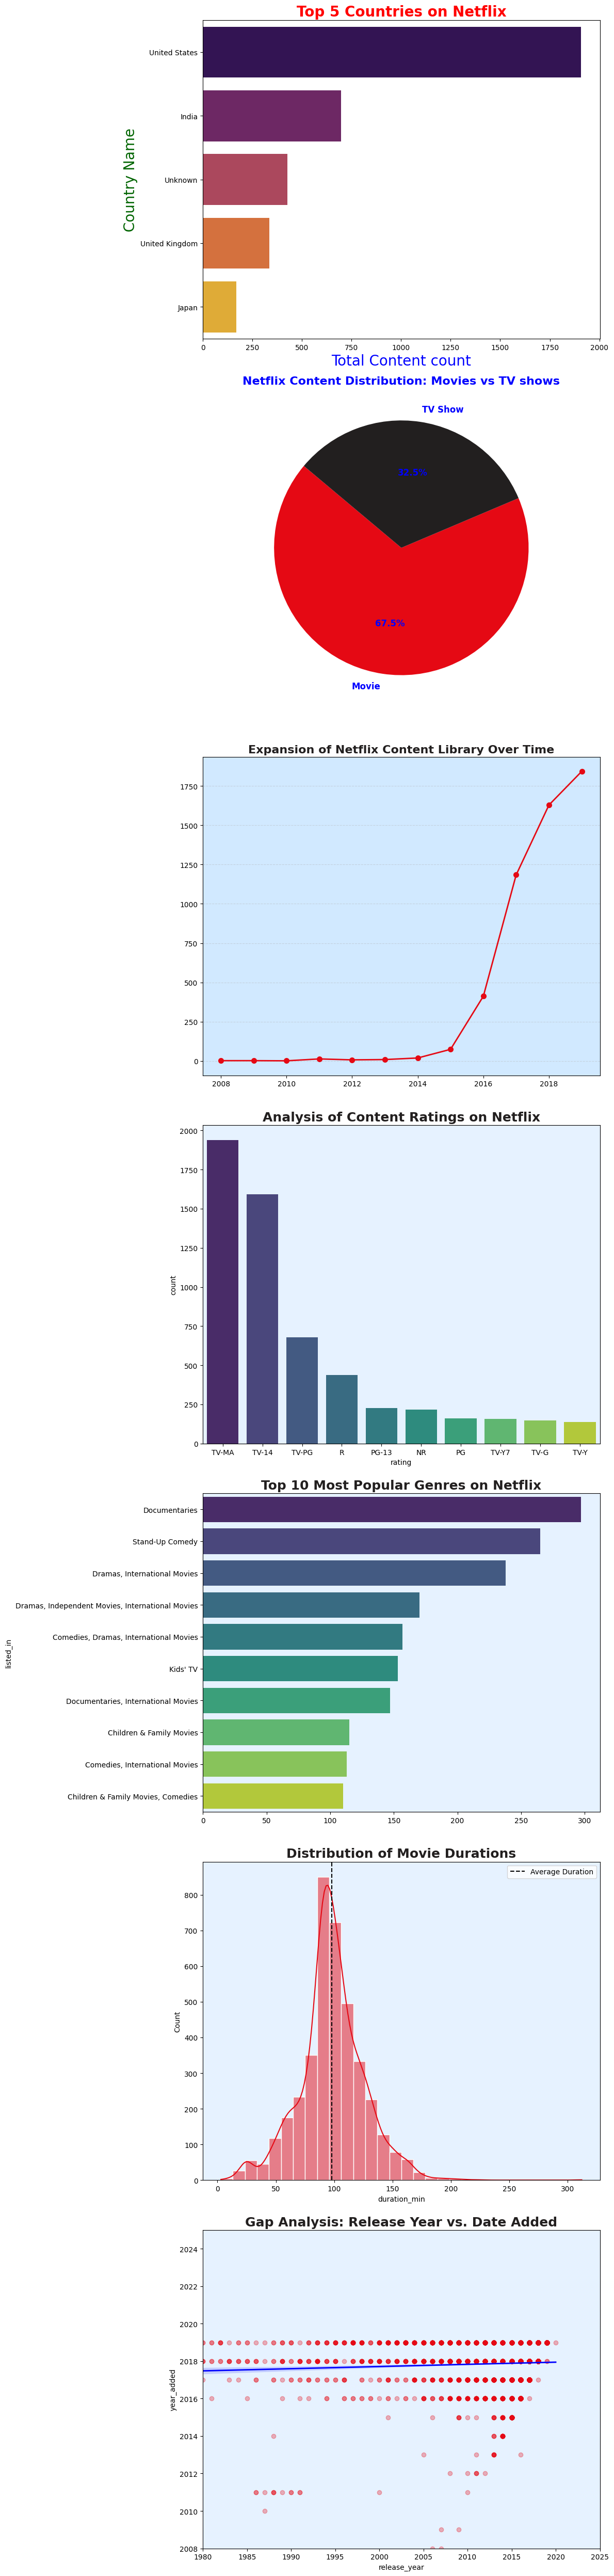

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path=('/kaggle/input/datasets/litonislam/netflix-data-analysis-trends-and-insights/Netflix_Title_Cleaned.csv')
df=pd.read_csv(file_path)

fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(12, 50))
sns.countplot(y='country', data=df, order=df['country'].value_counts().index[:5],
              palette='inferno', ax=axes[0])
axes[0].set_title('Top 5 Countries on Netflix', fontsize=20, fontweight='bold', color='red')
axes[0].set_xlabel('Total Content count', fontsize=20, color='blue')
axes[0].set_ylabel('Country Name', fontsize=20, color='darkgreen')
type_counts = df['type'].value_counts()
colors = ['#E50914', '#221F1F']
axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140,
            colors=colors, textprops={'color': "blue", 'fontsize': 12, 'weight': 'bold'})
axes[1].set_title('Netflix Content Distribution: Movies vs TV shows', fontsize=16, color='blue', weight='bold')
df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
netflix_growth = df['year_added'].value_counts().sort_index()
axes[2].set_facecolor("#D1E9FF")
axes[2].plot(netflix_growth.index, netflix_growth.values, color='#E50914', marker='o', linewidth=2, markersize=7)
axes[2].set_title('Expansion of Netflix Content Library Over Time', fontsize=16, fontweight='bold', color='#221F1F')
axes[2].grid(axis='y', linestyle='--', alpha=0.4)
axes[3].set_facecolor("#E6F2FF")
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index[:10], palette='viridis', ax=axes[3])
axes[3].set_title('Analysis of Content Ratings on Netflix', fontsize=18, fontweight='bold', color='#221F1F')
axes[4].set_facecolor("#E6F2FF")
top_genres = df['listed_in'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis', ax=axes[4])
axes[4].set_title('Top 10 Most Popular Genres on Netflix', fontsize=18, fontweight='bold', color='#221F1F')
movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_min'] = movie_df['duration'].str.replace(' min', '').astype(float)
axes[5].set_facecolor("#E6F2FF")
sns.histplot(movie_df['duration_min'], bins=30, kde=True, color='#E50914', edgecolor='white', ax=axes[5])
axes[5].axvline(movie_df['duration_min'].mean(), color='black', linestyle='--', label='Average Duration')
axes[5].set_title('Distribution of Movie Durations', fontsize=18, fontweight='bold', color='#221F1F')
axes[5].legend()
viz_df = df.dropna(subset=['year_added', 'release_year'])
axes[6].set_facecolor("#E6F2FF")
sns.regplot(x='release_year', y='year_added', data=viz_df,
            scatter_kws={'alpha': 0.3, 'color': '#E50914'}, line_kws={'color': 'blue', 'linewidth': 2}, ax=axes[6])
axes[6].set_title('Gap Analysis: Release Year vs. Date Added', fontsize=18, fontweight='bold', color='#221F1F')
axes[6].set_xlim(1980, 2025)
axes[6].set_ylim(2008, 2025)
plt.tight_layout()
plt.show()


# 🎬 Netflix Content Analysis: Trends & Insights
### Exploratory Data Analysis (EDA) 🔍

---

## 📌 Executive Summary
This notebook explores the vast Netflix library to understand its content strategy, global reach, and growth over the years. By analyzing the dataset, we've uncovered key patterns between **Movies** and **TV Shows**.

## 🚀 Key Objectives:
* **Content Distribution:** Comparison between Movies and TV Shows.
* **Top Contributors:** Identifying the top 5 countries producing content.
* **Growth Trends:** How content additions have changed over time.

---